# Task 4: Neural Machine Translation with Attention

This notebook adds an attention mechanism to the Task 3 LSTM encoder-decoder model.

It covers:

1. Word-level EN → PT Seq2Seq with attention
2. Training and validation
3. BLEU and chrF evaluation
4. Comparison against the Task 3 non-attention model
5. Attention weight visualization for one sample sentence

Expected input files from Task 2:

```text
outputs_task2/clean_sample_10_percent.en
outputs_task2/clean_sample_10_percent.pt
```

Optional comparison file from Task 3:

```text
outputs_task3_updated/final_task3_results_summary.csv
```

## 1. Imports

In [1]:
from pathlib import Path
from collections import Counter
from dataclasses import dataclass, asdict
from typing import List, Tuple
import random
import math
import time

import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

## 2. Configuration

In [2]:
try:
    PROJECT_DIR = Path(__file__).resolve().parent
except NameError:
    PROJECT_DIR = Path.cwd()

DATA_DIR = PROJECT_DIR / "outputs_task2"
EN_PATH = DATA_DIR / "clean_sample_10_percent.en"
PT_PATH = DATA_DIR / "clean_sample_10_percent.pt"

TASK3_RESULTS_PATH = PROJECT_DIR / "outputs_task3_updated" / "final_task3_results_summary.csv"

OUTPUT_DIR = PROJECT_DIR / "outputs_task4_attention"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42

# For development. Increase or set to None for a more serious run.
MAX_PAIRS = 30000

MAX_LEN_WORD = 50
MAX_VOCAB_SIZE = 20000
MIN_FREQ = 2

BATCH_SIZE = 64
NUM_EPOCHS = 5
LEARNING_RATE = 1e-3
CLIP = 1.0
TEACHER_FORCING_RATIO = 0.5

EMB_DIM = 256
HID_DIM = 512
DROPOUT = 0.3

PAD = "<pad>"
UNK = "<unk>"
SOS = "<sos>"
EOS = "<eos>"

DEVICE = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Project directory:", PROJECT_DIR)
print("EN file:", EN_PATH, EN_PATH.exists())
print("PT file:", PT_PATH, PT_PATH.exists())
print("Task 3 result file:", TASK3_RESULTS_PATH, TASK3_RESULTS_PATH.exists())
print("Output directory:", OUTPUT_DIR)
print("Device:", DEVICE)

Project directory: /Users/baturu/Documents/git/NLP/machine_translation
EN file: /Users/baturu/Documents/git/NLP/machine_translation/outputs_task2/clean_sample_10_percent.en True
PT file: /Users/baturu/Documents/git/NLP/machine_translation/outputs_task2/clean_sample_10_percent.pt True
Task 3 result file: /Users/baturu/Documents/git/NLP/machine_translation/outputs_task3_updated/final_task3_results_summary.csv True
Output directory: /Users/baturu/Documents/git/NLP/machine_translation/outputs_task4_attention
Device: mps


## 3. Load data and split

In [3]:
def set_seed(seed=42):
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def read_lines(path: Path):
    with open(path, "r", encoding="utf-8") as f:
        return [line.rstrip("\n") for line in f]

def load_pairs(en_path: Path, pt_path: Path):
    en = read_lines(en_path)
    pt = read_lines(pt_path)
    assert len(en) == len(pt), "EN and PT files must have the same number of lines."
    return [(e, p) for e, p in zip(en, pt) if e.strip() and p.strip()]

def split_pairs(pairs, test_ratio=0.20, val_ratio=0.10, seed=42):
    rng = random.Random(seed)
    pairs = pairs[:]
    rng.shuffle(pairs)

    n = len(pairs)
    n_test = int(test_ratio * n)
    n_val = int(val_ratio * n)

    test_pairs = pairs[:n_test]
    val_pairs = pairs[n_test:n_test+n_val]
    train_pairs = pairs[n_test+n_val:]

    return train_pairs, val_pairs, test_pairs

set_seed(RANDOM_SEED)

pairs = load_pairs(EN_PATH, PT_PATH)
if MAX_PAIRS is not None:
    pairs = pairs[:MAX_PAIRS]

train_pairs, val_pairs, test_pairs = split_pairs(pairs, seed=RANDOM_SEED)

split_df = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "pairs": [len(train_pairs), len(val_pairs), len(test_pairs)],
    "ratio": [len(train_pairs)/len(pairs), len(val_pairs)/len(pairs), len(test_pairs)/len(pairs)]
})

display(split_df)
print("Example EN:", train_pairs[0][0])
print("Example PT:", train_pairs[0][1])

,split,pairs,ratio
0,train,21000,0.7
1,validation,3000,0.1
2,test,6000,0.2


Example EN: it would, therefore, not surprise me if certain groupings, including in this parliament, were to claim that this agreement does not go far enough.
Example PT: assim sendo, ficaria surpreendido se certos grupos, inclusive neste parlamento, dissessem que este acordo não vai suficientemente longe.


## 4. Tokenizer and vocabulary

In [4]:
def word_tokenize(text: str):
    return text.strip().split()

class Vocab:
    def __init__(self, texts, tokenizer, max_size=None, min_freq=1):
        self.tokenizer = tokenizer
        self.specials = [PAD, UNK, SOS, EOS]

        counter = Counter()
        for text in texts:
            counter.update(tokenizer(text))

        tokens = []
        for tok, freq in counter.most_common():
            if freq < min_freq:
                continue
            if tok in self.specials:
                continue
            tokens.append(tok)
            if max_size is not None and len(tokens) >= max_size - len(self.specials):
                break

        self.itos = self.specials + tokens
        self.stoi = {tok: i for i, tok in enumerate(self.itos)}

        self.pad_idx = self.stoi[PAD]
        self.unk_idx = self.stoi[UNK]
        self.sos_idx = self.stoi[SOS]
        self.eos_idx = self.stoi[EOS]

    def __len__(self):
        return len(self.itos)

    def encode(self, text, add_sos_eos=True):
        ids = [self.stoi.get(tok, self.unk_idx) for tok in self.tokenizer(text)]
        if add_sos_eos:
            ids = [self.sos_idx] + ids + [self.eos_idx]
        return ids

    def decode(self, ids, remove_specials=True):
        tokens = []
        for idx in ids:
            tok = self.itos[idx] if 0 <= idx < len(self.itos) else UNK
            if remove_specials and tok in {PAD, SOS, EOS}:
                continue
            tokens.append(tok)
        return tokens

src_vocab = Vocab(
    [en for en, _ in train_pairs],
    tokenizer=word_tokenize,
    max_size=MAX_VOCAB_SIZE,
    min_freq=MIN_FREQ
)

trg_vocab = Vocab(
    [pt for _, pt in train_pairs],
    tokenizer=word_tokenize,
    max_size=MAX_VOCAB_SIZE,
    min_freq=MIN_FREQ
)

print("Source vocabulary size:", len(src_vocab))
print("Target vocabulary size:", len(trg_vocab))

Source vocabulary size: 14457
Target vocabulary size: 18693


## 5. Dataset and DataLoader

In [5]:
class TranslationDataset(Dataset):
    def __init__(self, pairs, src_vocab, trg_vocab, max_len):
        self.src_vocab = src_vocab
        self.trg_vocab = trg_vocab
        self.examples = []

        for src, trg in pairs:
            if len(word_tokenize(src)) > max_len or len(word_tokenize(trg)) > max_len:
                continue
            self.examples.append((src, trg))

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        src, trg = self.examples[idx]
        src_ids = self.src_vocab.encode(src)
        trg_ids = self.trg_vocab.encode(trg)
        return torch.tensor(src_ids, dtype=torch.long), torch.tensor(trg_ids, dtype=torch.long)

def make_collate_fn(src_pad_idx, trg_pad_idx):
    def collate_fn(batch):
        src_batch, trg_batch = zip(*batch)

        max_src_len = max(len(x) for x in src_batch)
        max_trg_len = max(len(x) for x in trg_batch)

        padded_src = torch.full((len(batch), max_src_len), src_pad_idx, dtype=torch.long)
        padded_trg = torch.full((len(batch), max_trg_len), trg_pad_idx, dtype=torch.long)

        for i, (src, trg) in enumerate(zip(src_batch, trg_batch)):
            padded_src[i, :len(src)] = src
            padded_trg[i, :len(trg)] = trg

        return padded_src, padded_trg
    return collate_fn

train_data = TranslationDataset(train_pairs, src_vocab, trg_vocab, MAX_LEN_WORD)
val_data = TranslationDataset(val_pairs, src_vocab, trg_vocab, MAX_LEN_WORD)
test_data = TranslationDataset(test_pairs, src_vocab, trg_vocab, MAX_LEN_WORD)

collate_fn = make_collate_fn(src_vocab.pad_idx, trg_vocab.pad_idx)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

src_batch, trg_batch = next(iter(train_loader))

print("Train examples:", len(train_data))
print("Validation examples:", len(val_data))
print("Test examples:", len(test_data))
print("Source batch shape:", src_batch.shape)
print("Target batch shape:", trg_batch.shape)

Train examples: 19424
Validation examples: 2785
Test examples: 5555
Source batch shape: torch.Size([64, 46])
Target batch shape: torch.Size([64, 52])


## 6. Attention model

This uses additive/Bahdanau-style attention. The encoder returns hidden states for all source positions. The decoder computes an attention distribution over these source states at every target decoding step.

In [6]:
class AttentionEncoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hid_dim, dropout, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim, padding_idx=pad_idx)
        self.rnn = nn.LSTM(emb_dim, hid_dim, batch_first=True)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        embedded = self.dropout(self.embedding(src))
        encoder_outputs, (hidden, cell) = self.rnn(embedded)
        return encoder_outputs, hidden, cell

class BahdanauAttention(nn.Module):
    def __init__(self, hid_dim):
        super().__init__()
        self.attn = nn.Linear(hid_dim * 2, hid_dim)
        self.v = nn.Linear(hid_dim, 1, bias=False)

    def forward(self, decoder_hidden, encoder_outputs, mask):
        # decoder_hidden: [batch, hid_dim]
        # encoder_outputs: [batch, src_len, hid_dim]
        src_len = encoder_outputs.shape[1]

        decoder_hidden = decoder_hidden.unsqueeze(1).repeat(1, src_len, 1)
        energy = torch.tanh(self.attn(torch.cat((decoder_hidden, encoder_outputs), dim=2)))
        attention = self.v(energy).squeeze(2)

        attention = attention.masked_fill(mask == 0, -1e10)
        return torch.softmax(attention, dim=1)

class AttentionDecoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hid_dim, dropout, pad_idx, attention):
        super().__init__()
        self.output_dim = output_dim
        self.attention = attention

        self.embedding = nn.Embedding(output_dim, emb_dim, padding_idx=pad_idx)
        self.rnn = nn.LSTM(emb_dim + hid_dim, hid_dim, batch_first=True)
        self.fc_out = nn.Linear(emb_dim + hid_dim * 2, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_token, hidden, cell, encoder_outputs, mask):
        # input_token: [batch]
        input_token = input_token.unsqueeze(1)
        embedded = self.dropout(self.embedding(input_token))

        attn_weights = self.attention(hidden[-1], encoder_outputs, mask)
        attn_weights_unsqueezed = attn_weights.unsqueeze(1)

        context = torch.bmm(attn_weights_unsqueezed, encoder_outputs)

        rnn_input = torch.cat((embedded, context), dim=2)
        output, (hidden, cell) = self.rnn(rnn_input, (hidden, cell))

        prediction_input = torch.cat(
            (output.squeeze(1), context.squeeze(1), embedded.squeeze(1)),
            dim=1
        )
        prediction = self.fc_out(prediction_input)

        return prediction, hidden, cell, attn_weights

class AttentionSeq2Seq(nn.Module):
    def __init__(self, encoder, decoder, src_pad_idx, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.src_pad_idx = src_pad_idx
        self.device = device

    def create_mask(self, src):
        return (src != self.src_pad_idx)

    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        batch_size = src.shape[0]
        trg_len = trg.shape[1]
        src_len = src.shape[1]
        trg_vocab_size = self.decoder.output_dim

        outputs = torch.zeros(batch_size, trg_len, trg_vocab_size, device=self.device)
        attentions = torch.zeros(batch_size, trg_len, src_len, device=self.device)

        encoder_outputs, hidden, cell = self.encoder(src)
        mask = self.create_mask(src)

        input_token = trg[:, 0]

        for t in range(1, trg_len):
            output, hidden, cell, attn_weights = self.decoder(
                input_token, hidden, cell, encoder_outputs, mask
            )

            outputs[:, t, :] = output
            attentions[:, t, :] = attn_weights

            teacher_force = random.random() < teacher_forcing_ratio
            top1 = output.argmax(1)
            input_token = trg[:, t] if teacher_force else top1

        return outputs, attentions

## 7. Training functions for attention model

In [7]:
def train_epoch_attention(model, dataloader, optimizer, criterion, clip, teacher_forcing_ratio):
    model.train()
    epoch_loss = 0

    for src, trg in dataloader:
        src = src.to(DEVICE)
        trg = trg.to(DEVICE)

        optimizer.zero_grad()

        output, _ = model(src, trg, teacher_forcing_ratio)

        output_dim = output.shape[-1]
        output = output[:, 1:, :].reshape(-1, output_dim)
        trg = trg[:, 1:].reshape(-1)

        loss = criterion(output, trg)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / max(1, len(dataloader))

@torch.no_grad()
def evaluate_loss_attention(model, dataloader, criterion):
    model.eval()
    epoch_loss = 0

    for src, trg in dataloader:
        src = src.to(DEVICE)
        trg = trg.to(DEVICE)

        output, _ = model(src, trg, teacher_forcing_ratio=0.0)

        output_dim = output.shape[-1]
        output = output[:, 1:, :].reshape(-1, output_dim)
        trg = trg[:, 1:].reshape(-1)

        loss = criterion(output, trg)
        epoch_loss += loss.item()

    return epoch_loss / max(1, len(dataloader))

## 8. Create and train attention model

In [8]:
set_seed(RANDOM_SEED)

attention = BahdanauAttention(HID_DIM)
encoder = AttentionEncoder(
    input_dim=len(src_vocab),
    emb_dim=EMB_DIM,
    hid_dim=HID_DIM,
    dropout=DROPOUT,
    pad_idx=src_vocab.pad_idx
)
decoder = AttentionDecoder(
    output_dim=len(trg_vocab),
    emb_dim=EMB_DIM,
    hid_dim=HID_DIM,
    dropout=DROPOUT,
    pad_idx=trg_vocab.pad_idx,
    attention=attention
)

attention_model = AttentionSeq2Seq(
    encoder=encoder,
    decoder=decoder,
    src_pad_idx=src_vocab.pad_idx,
    device=DEVICE
).to(DEVICE)

optimizer = optim.Adam(attention_model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss(ignore_index=trg_vocab.pad_idx)

best_val_loss = float("inf")
best_model_path = OUTPUT_DIR / "attention_en_to_pt_best.pt"
history = []

for epoch in range(1, NUM_EPOCHS + 1):
    start = time.time()

    train_loss = train_epoch_attention(
        attention_model,
        train_loader,
        optimizer,
        criterion,
        CLIP,
        TEACHER_FORCING_RATIO
    )
    val_loss = evaluate_loss_attention(attention_model, val_loader, criterion)

    elapsed = time.time() - start

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "train_ppl": math.exp(min(train_loss, 20)),
        "val_ppl": math.exp(min(val_loss, 20)),
        "time_sec": elapsed
    }
    history.append(row)

    print(
        f"Epoch {epoch:02d} | "
        f"train loss {train_loss:.4f} | val loss {val_loss:.4f} | "
        f"train ppl {row['train_ppl']:.2f} | val ppl {row['val_ppl']:.2f} | "
        f"time {elapsed:.1f}s"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(attention_model.state_dict(), best_model_path)
        print("Saved best attention model:", best_model_path)

history_df = pd.DataFrame(history)
display(history_df)
history_df.to_csv(OUTPUT_DIR / "attention_training_history.csv", index=False)

attention_model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))

Epoch 01 | train loss 6.5788 | val loss 6.3232 | train ppl 719.65 | val ppl 557.35 | time 913.4s
Saved best attention model: /Users/baturu/Documents/git/NLP/machine_translation/outputs_task4_attention/attention_en_to_pt_best.pt
Epoch 02 | train loss 5.7821 | val loss 5.9693 | train ppl 324.43 | val ppl 391.23 | time 866.6s
Saved best attention model: /Users/baturu/Documents/git/NLP/machine_translation/outputs_task4_attention/attention_en_to_pt_best.pt
Epoch 03 | train loss 5.1754 | val loss 5.7772 | train ppl 176.86 | val ppl 322.85 | time 840.2s
Saved best attention model: /Users/baturu/Documents/git/NLP/machine_translation/outputs_task4_attention/attention_en_to_pt_best.pt
Epoch 04 | train loss 4.6679 | val loss 5.6672 | train ppl 106.47 | val ppl 289.21 | time 1977.6s
Saved best attention model: /Users/baturu/Documents/git/NLP/machine_translation/outputs_task4_attention/attention_en_to_pt_best.pt
Epoch 05 | train loss 4.2283 | val loss 5.6342 | train ppl 68.60 | val ppl 279.84 | tim

,epoch,train_loss,val_loss,train_ppl,val_ppl,time_sec
0,1,6.578766,6.323200,719.651033,557.353546,913.391256
1,2,5.782060,5.969290,324.426853,391.227871,866.640622
2,3,5.175358,5.777193,176.859863,322.851748,840.213538
3,4,4.667853,5.667167,106.468913,289.214137,1977.622212
4,5,4.228256,5.634214,68.597495,279.838999,719.939333


<All keys matched successfully>

## 9. Plot attention model training curve

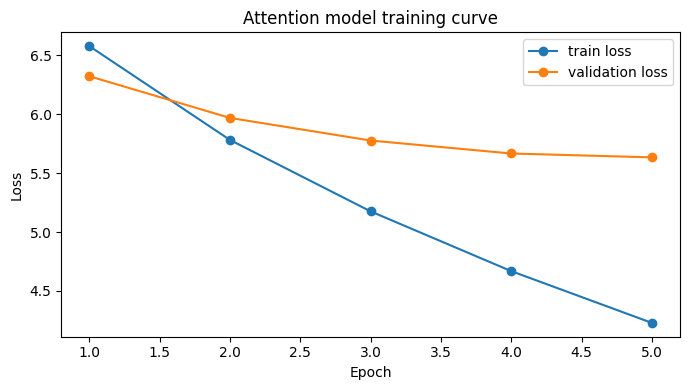

In [9]:
plt.figure(figsize=(7, 4))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="train loss")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Attention model training curve")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "attention_training_curve.png", dpi=200)
plt.show()

## 10. Translation with attention

In [10]:
@torch.no_grad()
def translate_with_attention(model, sentence, src_vocab, trg_vocab, max_output_len=80):
    model.eval()

    src_tokens = [SOS] + word_tokenize(sentence) + [EOS]
    src_ids = src_vocab.encode(sentence)
    src_tensor = torch.tensor(src_ids, dtype=torch.long).unsqueeze(0).to(DEVICE)

    encoder_outputs, hidden, cell = model.encoder(src_tensor)
    mask = model.create_mask(src_tensor)

    input_token = torch.tensor([trg_vocab.sos_idx], dtype=torch.long).to(DEVICE)

    output_ids = []
    attention_rows = []

    for _ in range(max_output_len):
        output, hidden, cell, attn_weights = model.decoder(
            input_token, hidden, cell, encoder_outputs, mask
        )

        pred_id = output.argmax(1).item()

        if pred_id == trg_vocab.eos_idx:
            break

        output_ids.append(pred_id)
        attention_rows.append(attn_weights.squeeze(0).detach().cpu())

        input_token = torch.tensor([pred_id], dtype=torch.long).to(DEVICE)

    output_tokens = trg_vocab.decode(output_ids)

    if attention_rows:
        attention_matrix = torch.stack(attention_rows).numpy()
    else:
        attention_matrix = None

    return output_tokens, attention_matrix, src_tokens

## 11. Inspect sample translations

In [11]:
for i in range(5):
    src, ref = test_data.examples[i]
    hyp_tokens, attn, src_tokens = translate_with_attention(
        attention_model,
        src,
        src_vocab,
        trg_vocab,
        max_output_len=80
    )

    print(f"Example {i+1}")
    print("SRC:", src)
    print("REF:", ref)
    print("HYP:", " ".join(hyp_tokens))
    print("-" * 80)

Example 1
SRC: it is not sufficient to devote significant sums to decommissioning outdated power stations - we must also pay attention to maintaining them.
REF: não é suficiente destinar somas significativas para o desmantelamento das centrais ultrapassadas; temos também de prestar atenção à sua manutenção.
HYP: não é fácil de de de <unk> de <unk> de <unk> de de de de de de de de para a de de de de de de
--------------------------------------------------------------------------------
Example 2
SRC: i would ask these same member states to introduce legislative measures to promote gender balance in positions of responsibility, especially in private companies.
REF: solicitaria a esses mesmos estados-membros que introduzissem medidas legislativas de promoção do equilíbrio de género nas posições de responsabilidade, especialmente em companhias privadas.
HYP: gostaria de estas estas estados-membros estados-membros a medidas medidas para promover a promover a em em em em em em em em em especi

## 12. BLEU and chrF evaluation

In [12]:
def ngrams(tokens, n):
    return [tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1)]

def corpus_bleu(references, hypotheses, max_n=4):
    clipped_counts = [0] * max_n
    total_counts = [0] * max_n
    ref_len = 0
    hyp_len = 0

    for ref, hyp in zip(references, hypotheses):
        ref_len += len(ref)
        hyp_len += len(hyp)

        for n in range(1, max_n + 1):
            ref_counts = Counter(ngrams(ref, n))
            hyp_counts = Counter(ngrams(hyp, n))

            total_counts[n-1] += sum(hyp_counts.values())

            for gram, count in hyp_counts.items():
                clipped_counts[n-1] += min(count, ref_counts.get(gram, 0))

    precisions = [(c + 1) / (t + 1) for c, t in zip(clipped_counts, total_counts)]
    log_precision = sum(math.log(p) for p in precisions) / max_n

    if hyp_len == 0:
        return 0.0

    bp = 1.0 if hyp_len > ref_len else math.exp(1 - ref_len / max(1, hyp_len))
    return bp * math.exp(log_precision) * 100

def char_ngrams(text, n):
    return [text[i:i+n] for i in range(len(text)-n+1)]

def sentence_chrf(reference, hypothesis, max_n=6, beta=2.0):
    scores = []

    for n in range(1, max_n + 1):
        ref_counts = Counter(char_ngrams(reference, n))
        hyp_counts = Counter(char_ngrams(hypothesis, n))

        overlap = sum(min(count, ref_counts.get(g, 0)) for g, count in hyp_counts.items())

        hyp_total = max(1, sum(hyp_counts.values()))
        ref_total = max(1, sum(ref_counts.values()))

        precision = overlap / hyp_total
        recall = overlap / ref_total

        if precision == 0 and recall == 0:
            f_score = 0.0
        else:
            f_score = (1 + beta**2) * precision * recall / (beta**2 * precision + recall)

        scores.append(f_score)

    return sum(scores) / len(scores) * 100

def corpus_chrf(reference_texts, hypothesis_texts):
    return sum(sentence_chrf(r, h) for r, h in zip(reference_texts, hypothesis_texts)) / max(1, len(reference_texts))

@torch.no_grad()
def evaluate_attention_translation(model, test_examples, max_examples=500):
    eval_examples = test_examples[:max_examples]

    references_tokens = []
    hypotheses_tokens = []
    references_text = []
    hypotheses_text = []

    for src, ref in eval_examples:
        hyp_tokens, _, _ = translate_with_attention(
            model,
            src,
            src_vocab,
            trg_vocab,
            max_output_len=80
        )

        references_tokens.append(word_tokenize(ref))
        hypotheses_tokens.append(hyp_tokens)

        references_text.append(ref)
        hypotheses_text.append(" ".join(hyp_tokens))

    bleu = corpus_bleu(references_tokens, hypotheses_tokens)
    chrf = corpus_chrf(references_text, hypotheses_text)

    return bleu, chrf, references_text, hypotheses_text

attention_bleu, attention_chrf, refs, hyps = evaluate_attention_translation(
    attention_model,
    test_data.examples,
    max_examples=500
)

print(f"Attention EN → PT BLEU: {attention_bleu:.2f}")
print(f"Attention EN → PT chrF: {attention_chrf:.2f}")
print(f"Best validation loss: {best_val_loss:.4f}")

Attention EN → PT BLEU: 5.02
Attention EN → PT chrF: 29.64
Best validation loss: 5.6342


## 13. Compare with Task 3 non-attention model

In [13]:
attention_result = {
    "name": "attention_word_en_to_pt",
    "model_type": "with_attention",
    "src_lang": "en",
    "trg_lang": "pt",
    "tokenizer_type": "word",
    "best_val_loss": best_val_loss,
    "test_bleu": attention_bleu,
    "test_chrf": attention_chrf
}

comparison_rows = [attention_result]

if TASK3_RESULTS_PATH.exists():
    task3_df = pd.read_csv(TASK3_RESULTS_PATH)

    # Prefer the final random word-level EN→PT baseline.
    baseline_candidates = task3_df[
        (task3_df["src_lang"] == "en") &
        (task3_df["trg_lang"] == "pt") &
        (task3_df["tokenizer_type"] == "word") &
        (task3_df["embedding_type"] == "random")
    ].copy()

    if len(baseline_candidates) > 0:
        baseline = baseline_candidates.iloc[0].to_dict()
        comparison_rows.insert(0, {
            "name": baseline.get("name", "non_attention_word_en_to_pt"),
            "model_type": "without_attention",
            "src_lang": "en",
            "trg_lang": "pt",
            "tokenizer_type": "word",
            "best_val_loss": baseline.get("best_val_loss"),
            "test_bleu": baseline.get("test_bleu"),
            "test_chrf": baseline.get("test_chrf")
        })
    else:
        print("No matching EN→PT random word-level baseline found in Task 3 results.")
else:
    print("Task 3 result file not found. Only the attention result will be shown.")

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)

comparison_df.to_csv(OUTPUT_DIR / "attention_vs_no_attention_comparison.csv", index=False)
print("Saved:", OUTPUT_DIR / "attention_vs_no_attention_comparison.csv")

,name,model_type,src_lang,trg_lang,tokenizer_type,best_val_loss,test_bleu,test_chrf
0,final_word_en_to_pt_random,without_attention,en,pt,word,6.420367,0.260511,11.995645
1,attention_word_en_to_pt,with_attention,en,pt,word,5.634214,5.021653,29.644196


Saved: /Users/baturu/Documents/git/NLP/machine_translation/outputs_task4_attention/attention_vs_no_attention_comparison.csv


## 14. Plot attention vs no-attention comparison

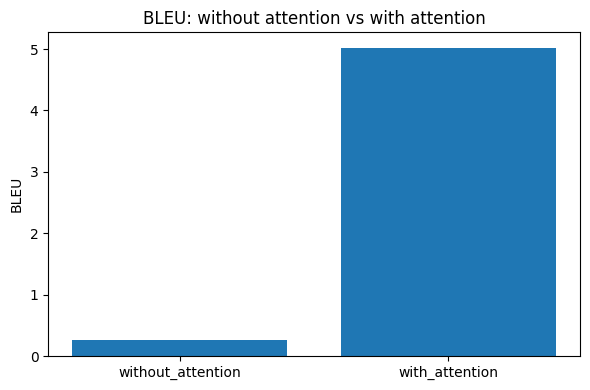

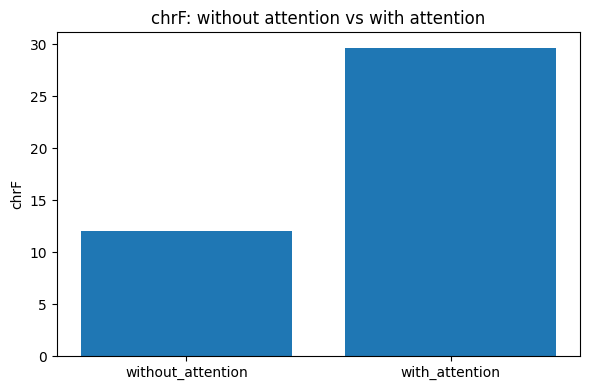

In [14]:
if len(comparison_df) >= 2:
    plt.figure(figsize=(6, 4))
    plt.bar(comparison_df["model_type"], comparison_df["test_bleu"])
    plt.ylabel("BLEU")
    plt.title("BLEU: without attention vs with attention")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "attention_vs_no_attention_bleu.png", dpi=200)
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.bar(comparison_df["model_type"], comparison_df["test_chrf"])
    plt.ylabel("chrF")
    plt.title("chrF: without attention vs with attention")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "attention_vs_no_attention_chrf.png", dpi=200)
    plt.show()

## 15. Visualize attention weights for one sample

Source: it is not sufficient to devote significant sums to decommissioning outdated power stations - we must also pay attention to maintaining them.
Reference: não é suficiente destinar somas significativas para o desmantelamento das centrais ultrapassadas; temos também de prestar atenção à sua manutenção.
Hypothesis: não é fácil de de de <unk> de <unk> de <unk> de de de de de de de de para a de de de de de de


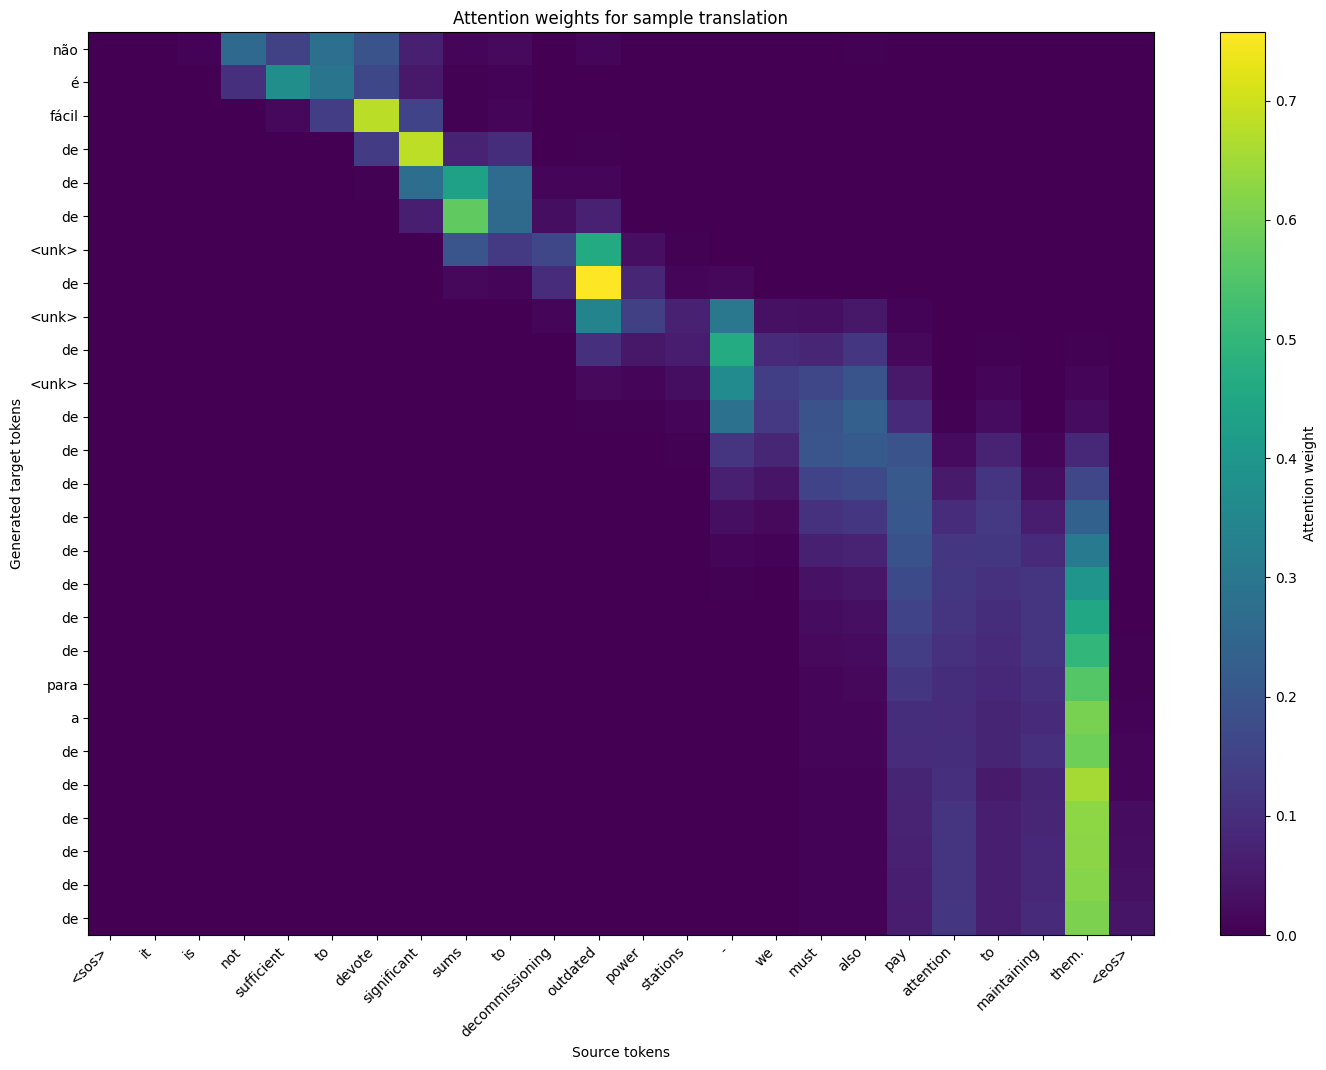

Saved attention visualization: /Users/baturu/Documents/git/NLP/machine_translation/outputs_task4_attention/sample_attention_weights.png


In [15]:
sample_index = 0

src, ref = test_data.examples[sample_index]
hyp_tokens, attention_matrix, src_tokens = translate_with_attention(
    attention_model,
    src,
    src_vocab,
    trg_vocab,
    max_output_len=80
)

print("Source:", src)
print("Reference:", ref)
print("Hypothesis:", " ".join(hyp_tokens))

if attention_matrix is None or len(hyp_tokens) == 0:
    print("No attention matrix available because the model produced no output tokens.")
else:
    # attention_matrix shape: [target_len, source_len]
    plt.figure(figsize=(max(8, len(src_tokens) * 0.6), max(5, len(hyp_tokens) * 0.4)))
    plt.imshow(attention_matrix, aspect="auto")
    plt.colorbar(label="Attention weight")

    plt.xticks(range(len(src_tokens)), src_tokens, rotation=45, ha="right")
    plt.yticks(range(len(hyp_tokens)), hyp_tokens)

    plt.xlabel("Source tokens")
    plt.ylabel("Generated target tokens")
    plt.title("Attention weights for sample translation")
    plt.tight_layout()

    attention_plot_path = OUTPUT_DIR / "sample_attention_weights.png"
    plt.savefig(attention_plot_path, dpi=200)
    plt.show()

    print("Saved attention visualization:", attention_plot_path)

## 16. Save sample predictions

In [16]:
pred_path = OUTPUT_DIR / "attention_sample_predictions.txt"

with open(pred_path, "w", encoding="utf-8") as f:
    for i in range(min(50, len(test_data.examples))):
        src, ref = test_data.examples[i]
        hyp_tokens, _, _ = translate_with_attention(attention_model, src, src_vocab, trg_vocab, max_output_len=80)
        hyp = " ".join(hyp_tokens)

        f.write(f"Example {i+1}\n")
        f.write(f"SRC: {src}\n")
        f.write(f"REF: {ref}\n")
        f.write(f"HYP: {hyp}\n")
        f.write("-" * 80 + "\n")

print("Saved:", pred_path)

Saved: /Users/baturu/Documents/git/NLP/machine_translation/outputs_task4_attention/attention_sample_predictions.txt


## 17. Report text template

You can adapt the following text in the report:

> We improved the previous LSTM encoder-decoder model by adding an additive attention mechanism. In the non-attention baseline, the decoder relies mainly on the final encoder hidden and cell states. In the attention-based model, the encoder returns hidden states for all source positions, and the decoder computes a normalized attention distribution over these states at every decoding step. This allows the decoder to focus on different source tokens while generating each target token.

> We compared the attention model with the previous non-attention word-level EN→PT model using validation loss, BLEU, and chrF. The attention weights were also visualized for a sample translation. The heatmap shows which source tokens received the highest attention while each target token was generated, providing an interpretable alignment between source and target sentences.